I- Import libraries

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

About Dataset
Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

Content
The datasets consists of several medical predictor variables and one target variable, Outcome. Predictor variables includes : 
Pregnancies : the number of pregnancies the patient has had;
BMI : Body mass index (weight in kg/(height in m)^2);
Insulin : Insulin level, 2-Hour serum insulin (mu U/ml);
Age : in years;
Glucose : Plasma glucose concentration a 2 hours in an oral glucose tolerance test;
BloodPressure : Diastolic blood pressure (mm Hg);
SkinThickness : Triceps skin fold thickness (mm);
DiabetesPedigreeFunction : Diabetes pedigree function.

Target variable is :
Outcome : Class variable (0 or 1) 268 of 768 are 1, the others are 0.

Objective 
Build a machine learning model which will accurately predict whether or not the patients in the dataset have diabetes or not.

II- Load the dataset

In [41]:
diabetes = pd.read_csv("/home/leonie/Downloads/diabetes.csv")

In [42]:
# Display the first five records of the dataset
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [43]:
# Dataset information
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


From this output, there is no missing values in our dataset.

III- Descriptive Analysis

III-1- Univariate Analysis

In [44]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [45]:
diabetes.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

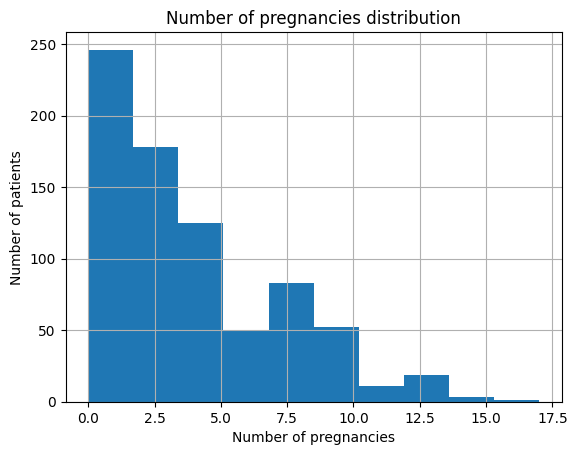

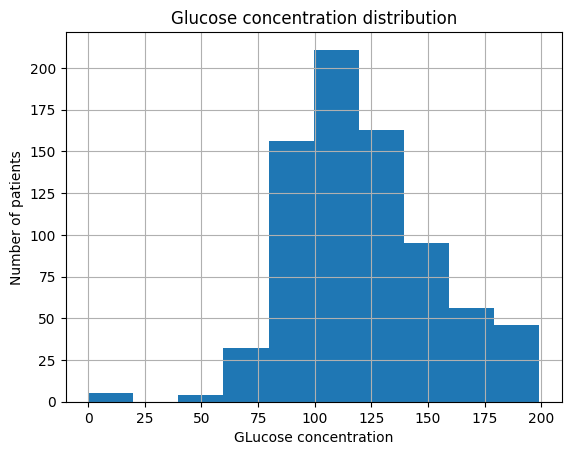

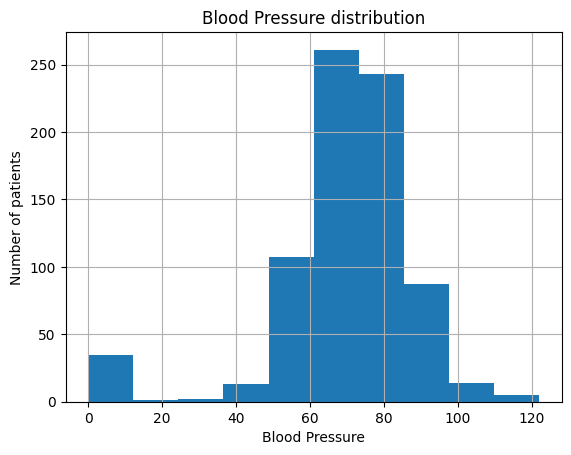

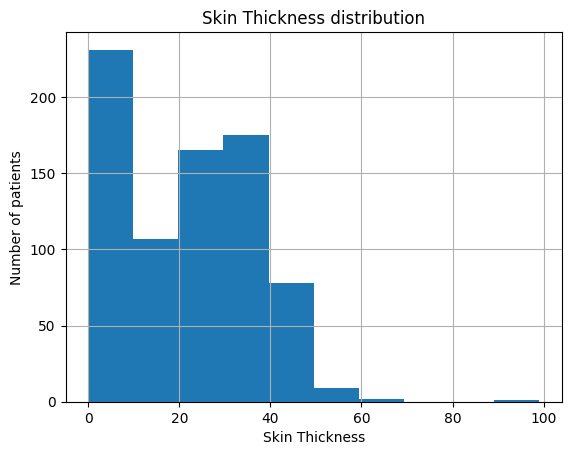

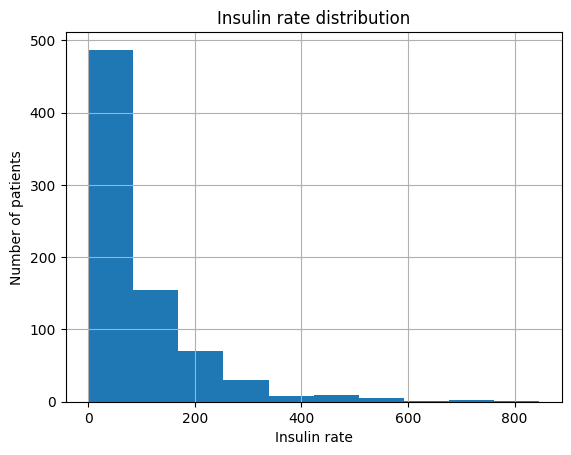

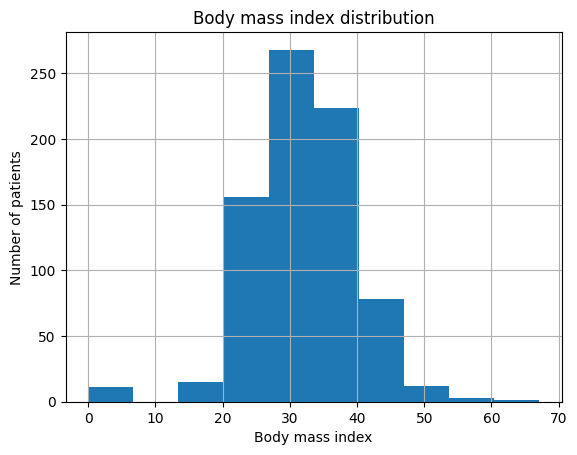

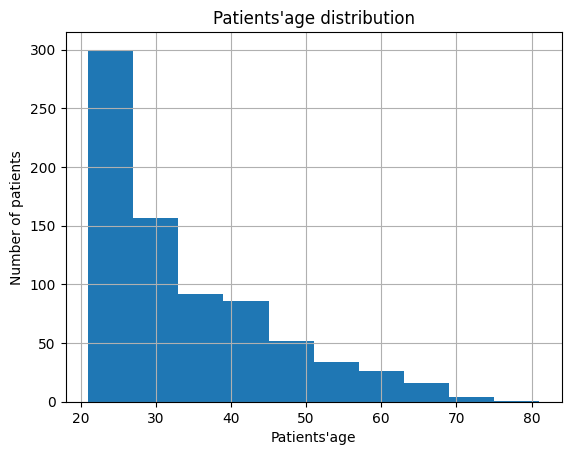

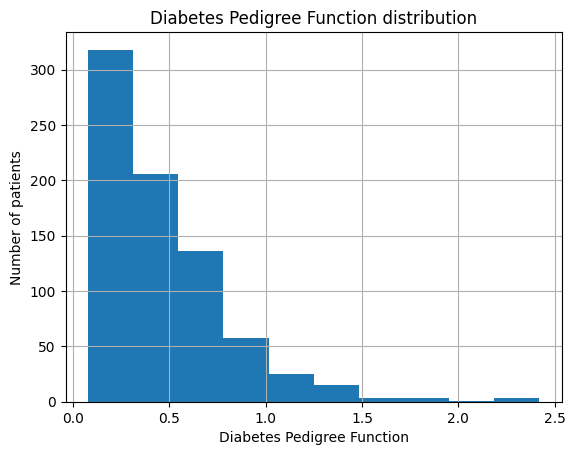

In [46]:
# Let's plot histogram to show the distribution of each variable.
# Number of pregnancies distribution
diabetes.Pregnancies.hist()
plt.title("Number of pregnancies distribution")
plt.xlabel("Number of pregnancies")
plt.ylabel("Number of patients")
plt.show()

# Glucose concentration distribution
diabetes.Glucose.hist()
plt.title("Glucose concentration distribution")
plt.xlabel("GLucose concentration")
plt.ylabel("Number of patients")
plt.show()

# Blood Pressure distribution
diabetes.BloodPressure.hist()
plt.title("Blood Pressure distribution")
plt.xlabel("Blood Pressure")
plt.ylabel("Number of patients")
plt.show()

# Skin Thickness distribution
diabetes.SkinThickness.hist()
plt.title("Skin Thickness distribution")
plt.xlabel("Skin Thickness")
plt.ylabel("Number of patients")
plt.show()

# Insulin rate distribution
diabetes.Insulin.hist()
plt.title("Insulin rate distribution")
plt.xlabel("Insulin rate")
plt.ylabel("Number of patients")
plt.show()

# Body mass index distribution
diabetes.BMI.hist()
plt.title("Body mass index distribution")
plt.xlabel("Body mass index")
plt.ylabel("Number of patients")
plt.show()

# Patients'age distribution
diabetes.Age.hist()
plt.title("Patients'age distribution")
plt.xlabel("Patients'age")
plt.ylabel("Number of patients")
plt.show()

# Diabetes Pedigree Function distribution
diabetes.DiabetesPedigreeFunction.hist()
plt.title("Diabetes Pedigree Function distribution")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Number of patients")
plt.show()

III-2- Bivariate Analysis

The distribution of the target variable "Outcome" vs each predicator

In [47]:
diabetes.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

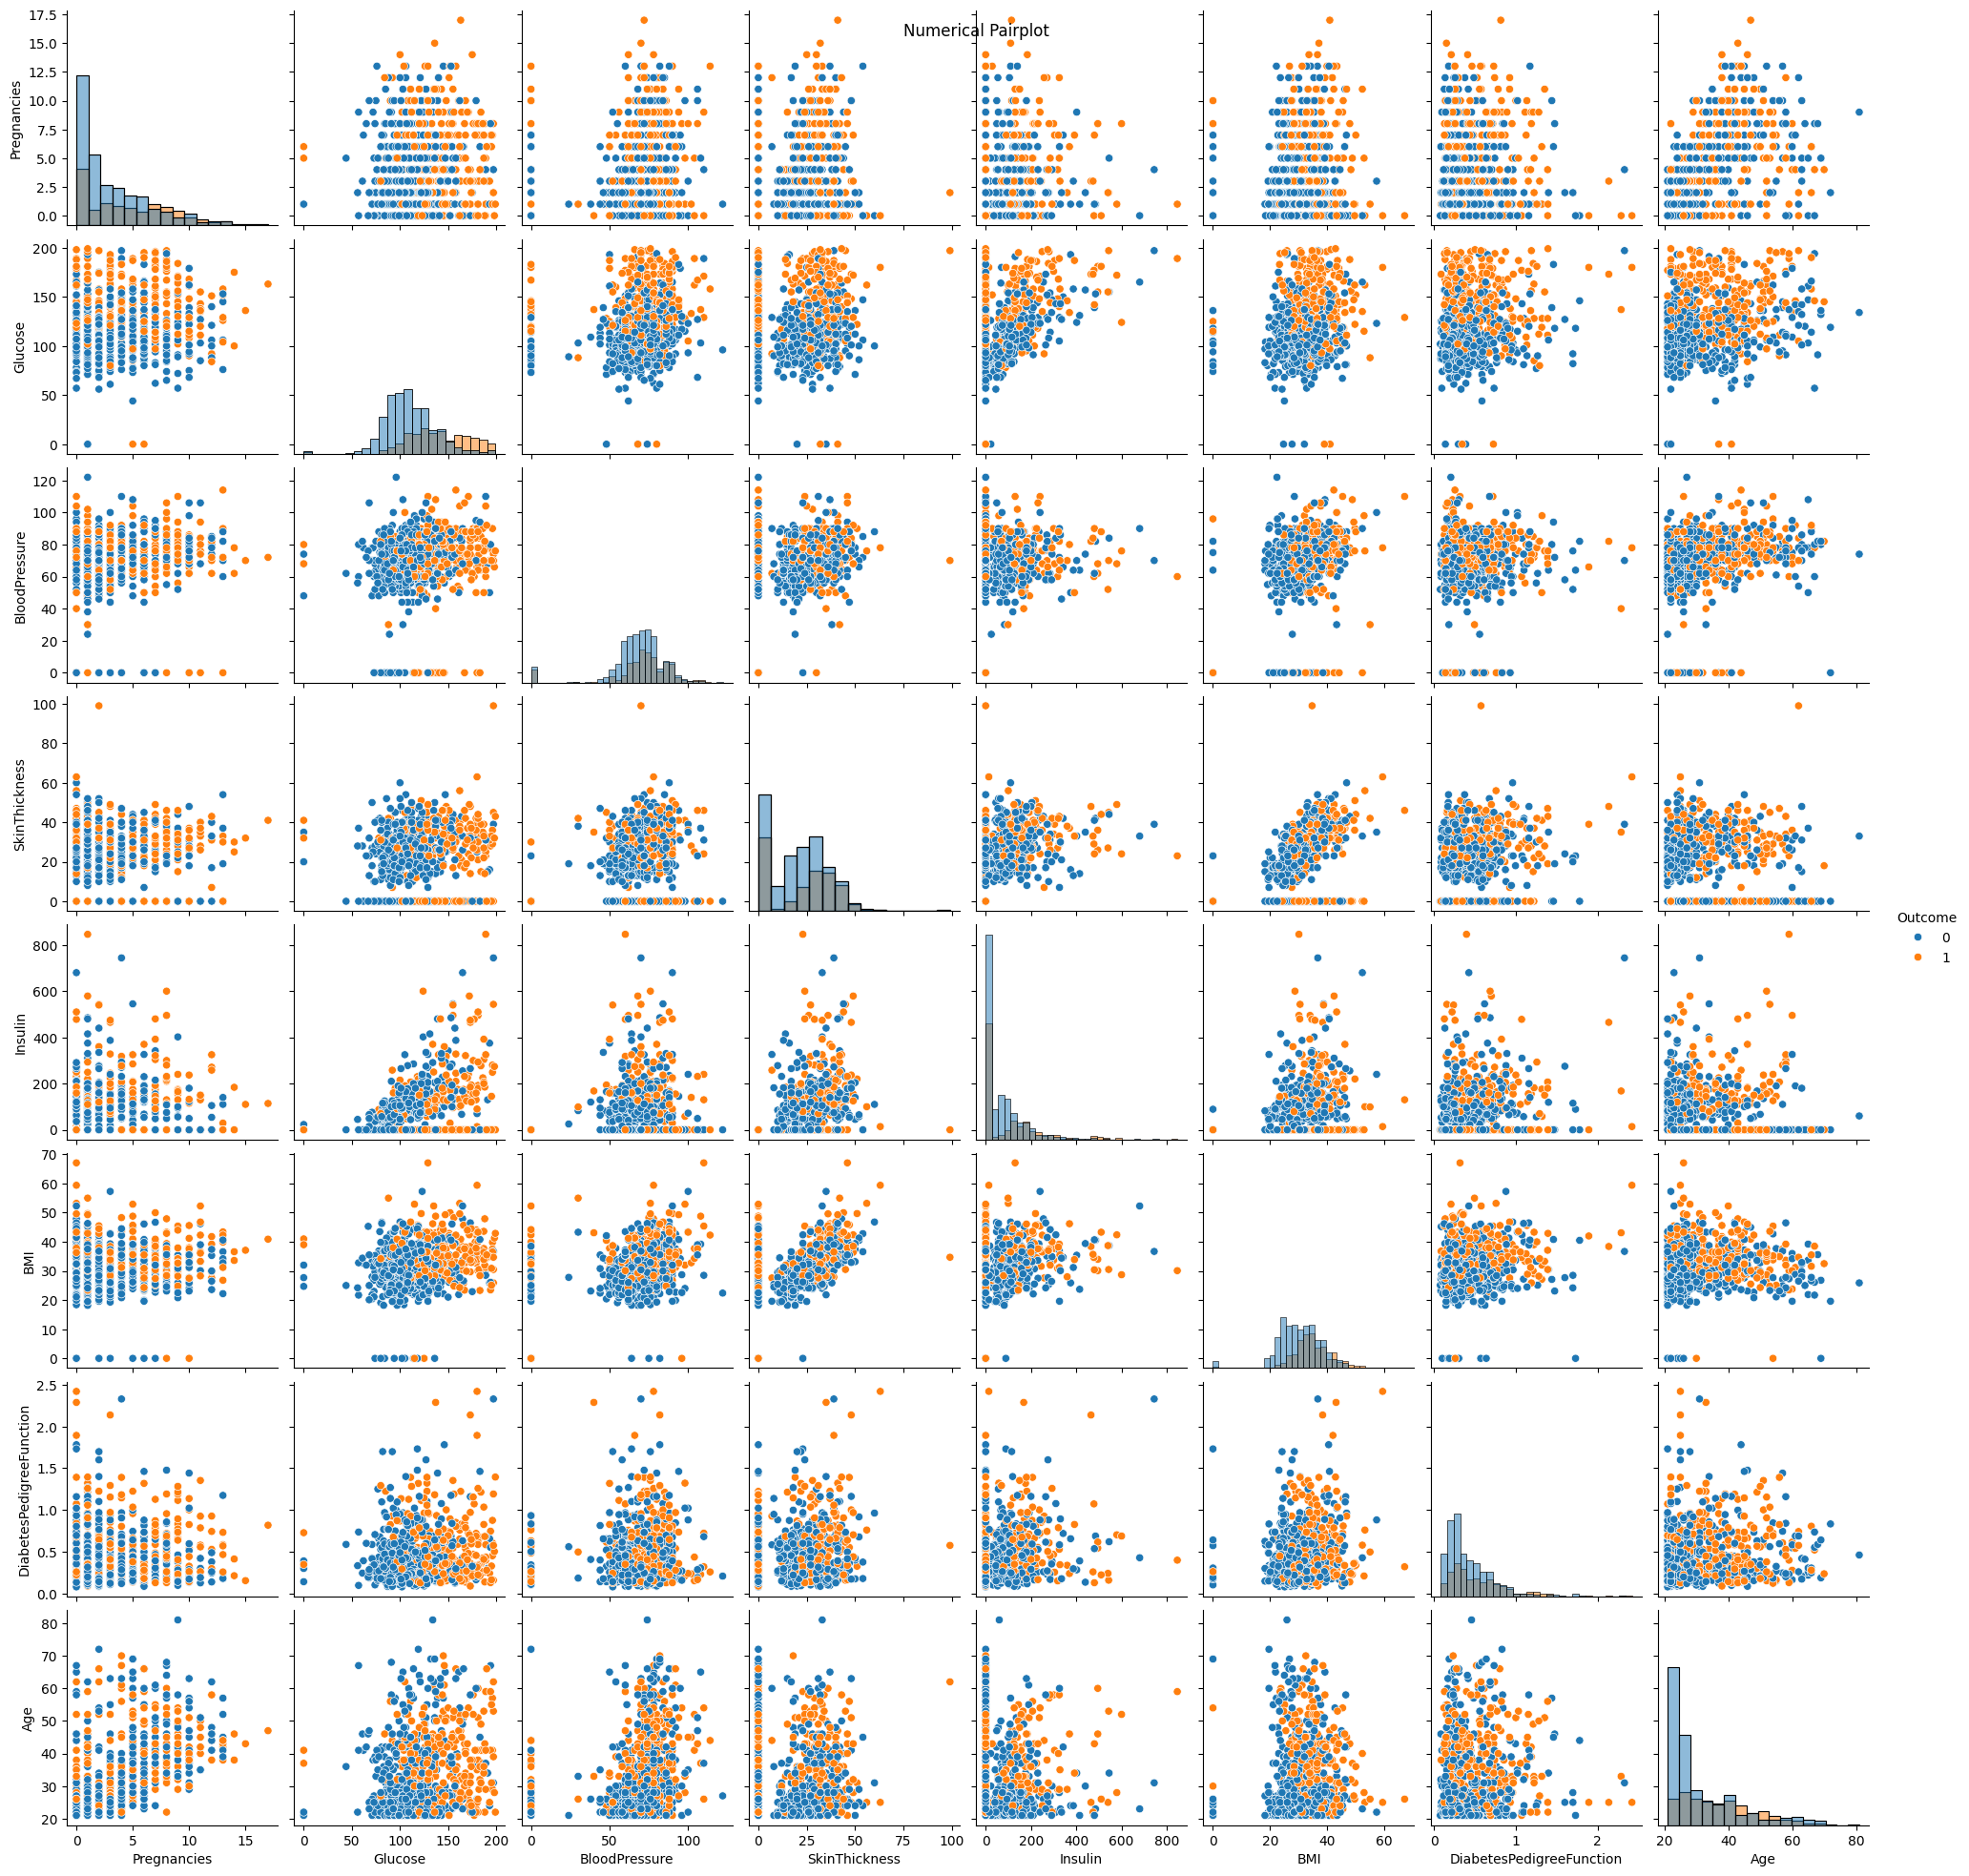

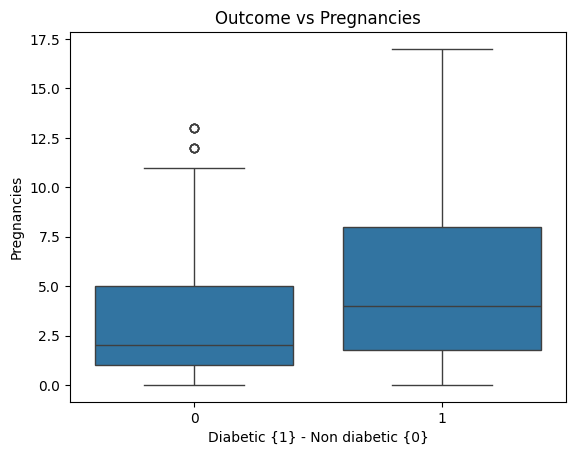

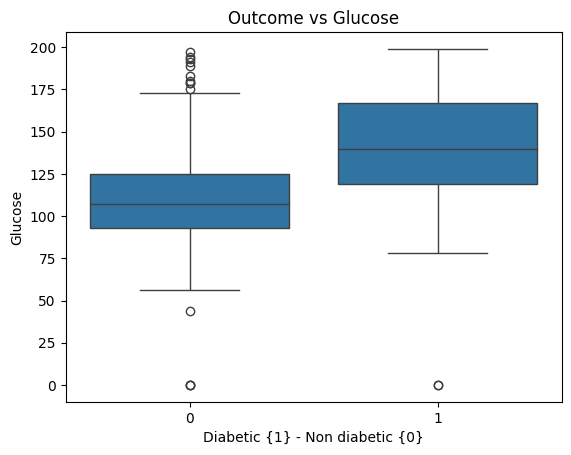

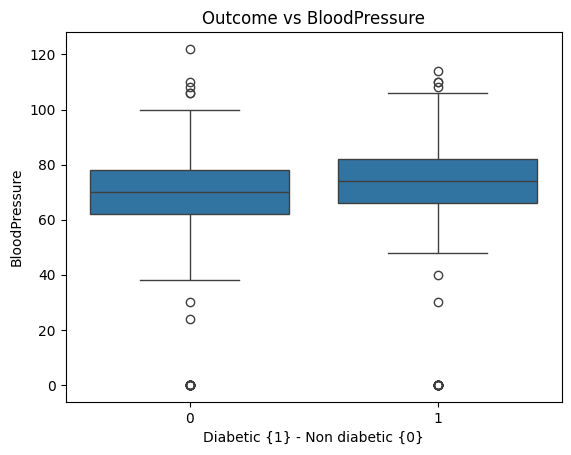

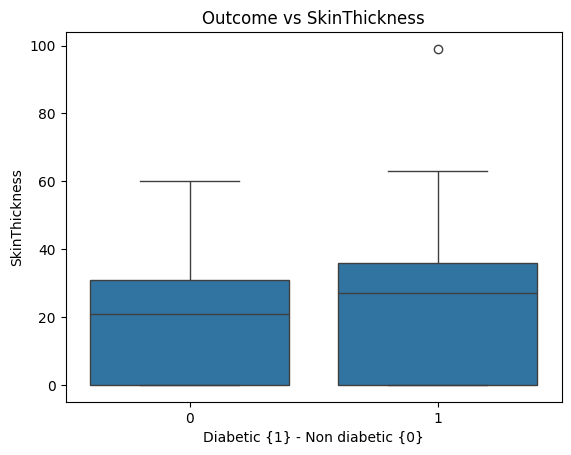

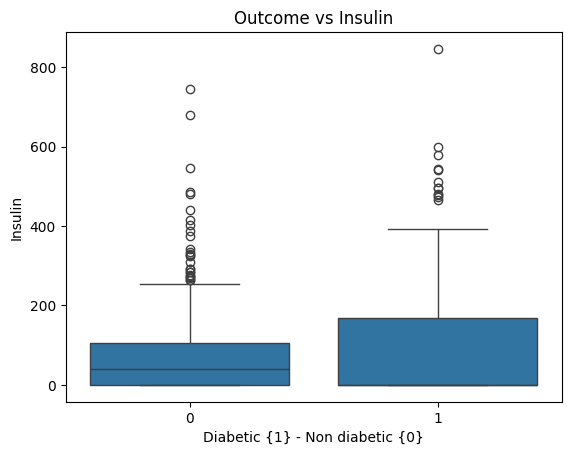

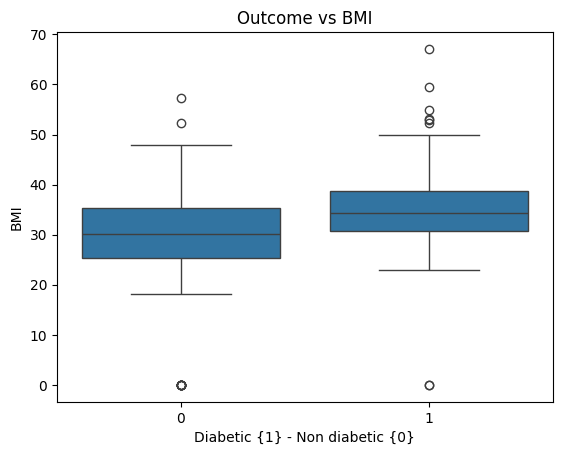

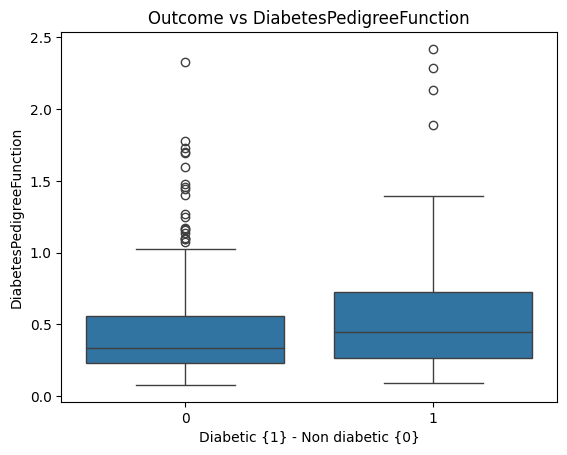

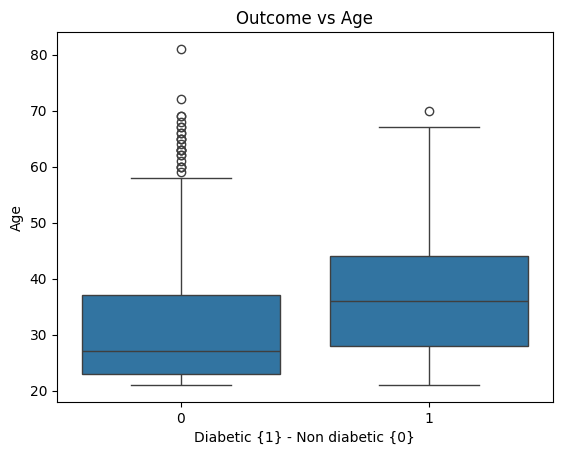

In [48]:
# Columns'name
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

# Pairplot
sns.pairplot(data=diabetes, hue="Outcome", diag_kind="hist")
plt.suptitle("Numerical Pairplot")
plt.show()
for col in cols:
    sns.boxplot(data=diabetes, x="Outcome", y=col)
    plt.title(f"Outcome vs {col}")
    plt.xlabel("Diabetic {1} - Non diabetic {0}")
    plt.ylabel(col)
    plt.show()

In [49]:
# Statistical tests
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
p_values = []
for col in cols:
    h, pval = kruskal(diabetes[col][diabetes["Outcome"] == 1], diabetes[col][diabetes["Outcome"] == 0])
    p_values.append(pval)

# Check significancy
is_significant = []
for pvalue in p_values:
    if pvalue < 0.05:
        is_significant.append("Oui")
    else:
        is_significant.append("Non")

# Present the result as a table
res = pd.DataFrame({"Variables": cols, "P-value": p_values, "Is_significant": is_significant})
res.set_index("Variables", inplace=True)
print(res)

                               P-value Is_significant
Variables                                            
Pregnancies               3.741498e-08            Oui
Glucose                   1.198015e-39            Oui
BloodPressure             7.553110e-05            Oui
SkinThickness             1.295554e-02            Oui
Insulin                   6.563377e-02            Non
BMI                       9.716371e-18            Oui
DiabetesPedigreeFunction  1.195553e-06            Oui
Age                       1.140509e-17            Oui


Check the presence of multicolinerity among predicators

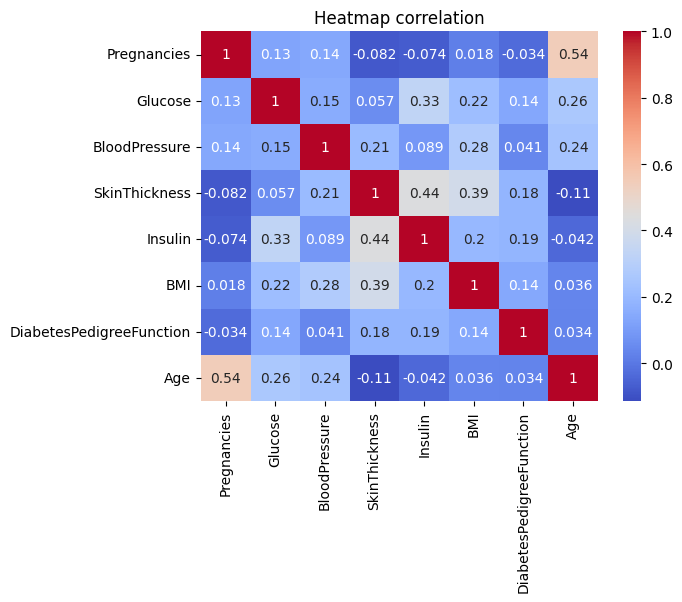

In [50]:
# Predicators
df_num = diabetes[cols]

sns.heatmap(df_num.corr(), cmap="coolwarm", annot=True)
plt.title("Heatmap correlation")
plt.show()

IV- Model Building

In [52]:
# Variables selections
X = diabetes.drop("Outcome", axis=1)
y = diabetes["Outcome"]

In [53]:
# Split the dataset into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Build the first tree

In [56]:
# The first tree
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

[Text(0.4602238581730769, 0.9642857142857143, 'Glucose <= 127.5\ngini = 0.453\nsamples = 614\nvalue = [401, 213]'),
 Text(0.1650390625, 0.8928571428571429, 'Age <= 28.5\ngini = 0.314\nsamples = 390\nvalue = [314, 76]'),
 Text(0.31263146033653844, 0.9285714285714286, 'True  '),
 Text(0.06009615384615385, 0.8214285714285714, 'BMI <= 30.95\ngini = 0.142\nsamples = 221\nvalue = [204, 17]'),
 Text(0.019230769230769232, 0.75, 'DiabetesPedigreeFunction <= 0.672\ngini = 0.016\nsamples = 124\nvalue = [123, 1]'),
 Text(0.009615384615384616, 0.6785714285714286, 'gini = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.028846153846153848, 0.6785714285714286, 'DiabetesPedigreeFunction <= 0.686\ngini = 0.117\nsamples = 16\nvalue = [15, 1]'),
 Text(0.019230769230769232, 0.6071428571428571, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.038461538461538464, 0.6071428571428571, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.10096153846153846, 0.75, 'BloodPressure <= 37.0\ngini = 0.275\nsamples

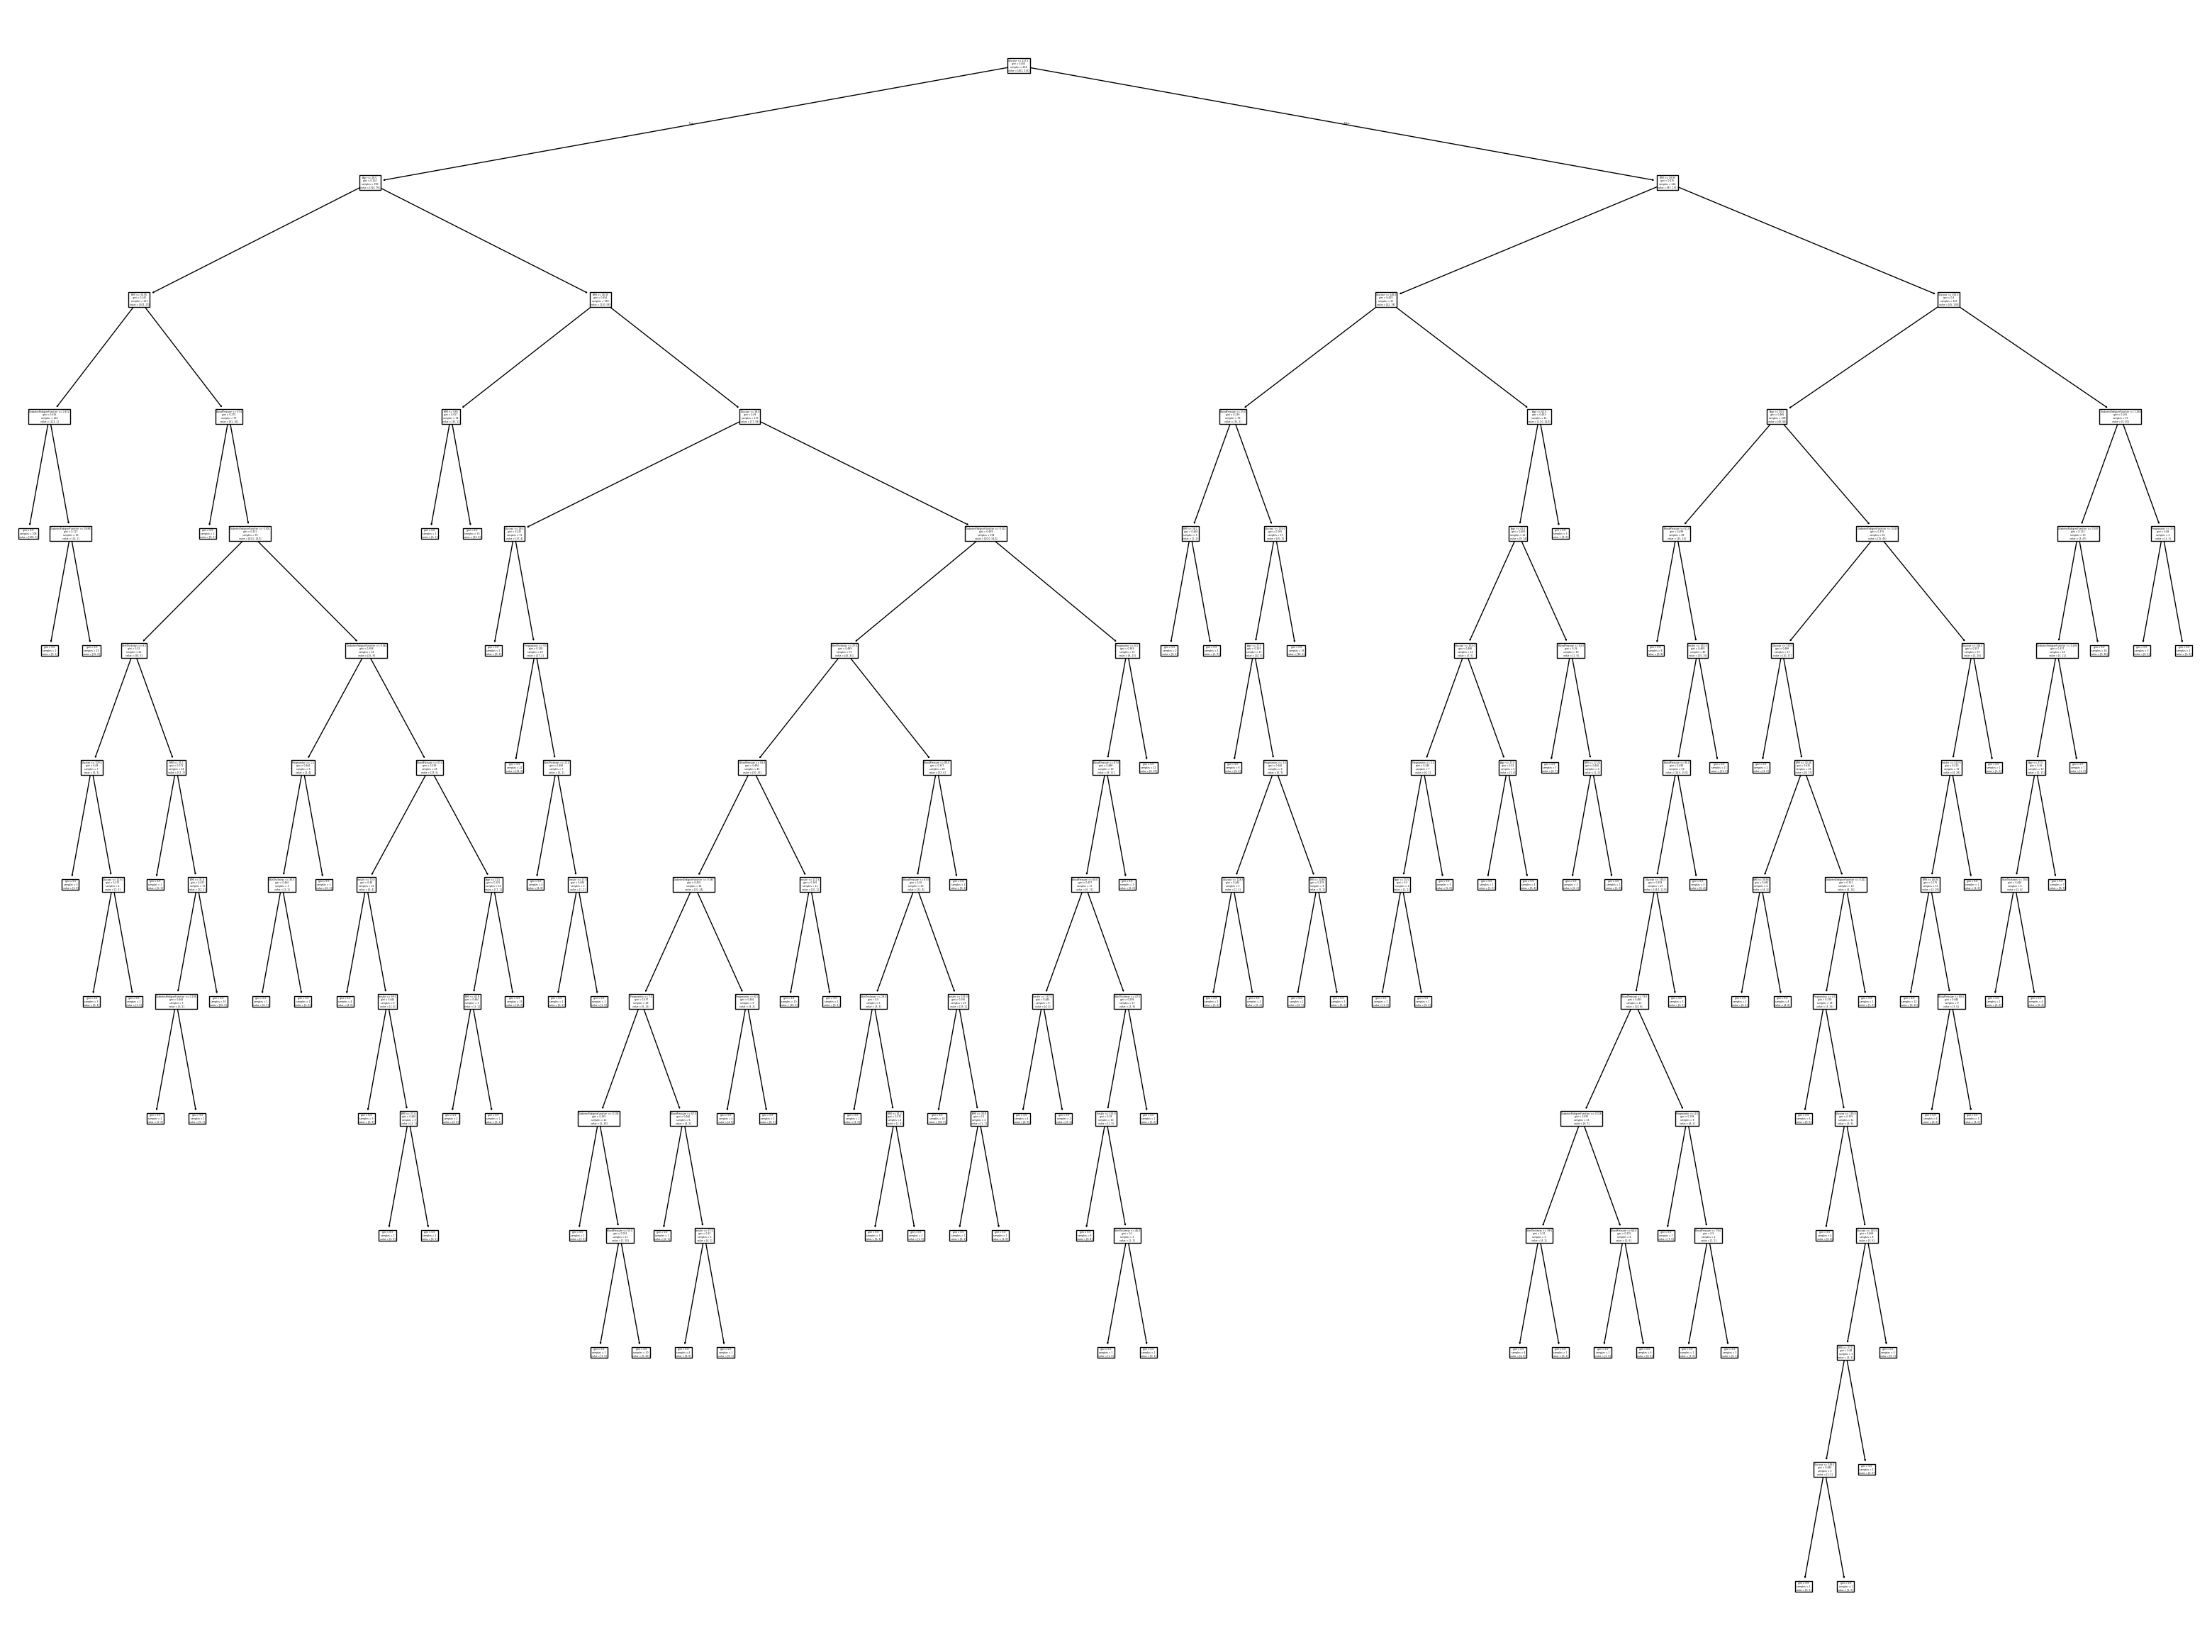

In [57]:
# Visualize the tree
plt.figure(figsize=(40, 30))
plot_tree(tree, feature_names=X.columns)

([<matplotlib.axis.XTick at 0x7b74c9ab34d0>,
 [Text(0, 0, 'Glucose'),
  Text(1, 0, 'BMI'),
  Text(2, 0, 'BloodPressure'),
  Text(3, 0, 'Age'),
  Text(4, 0, 'DiabetesPedigreeFunction'),
  Text(5, 0, 'Insulin'),
  Text(6, 0, 'SkinThickness'),
  Text(7, 0, 'Pregnancies')])

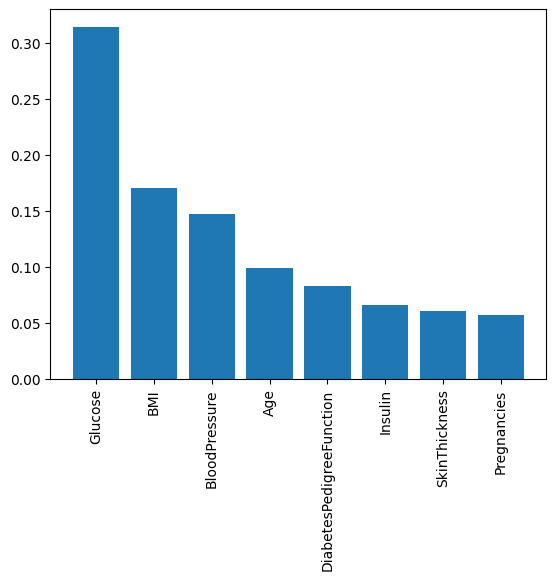

In [62]:
# Feature importance for each feature in the decision tree
importances = tree.feature_importances_
index = np.argsort(importances)[::-1]

plt.bar(range(X_train.shape[1]), importances[index])
plt.xticks(range(X_train.shape[1]), X.columns[index], rotation=90)

Evaluate the model performance

In [65]:
# On the training dataset
# Prediction on the training dataset
y_train_pred = tree.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print("Performance on the training dataset")
print("Train Accuracy : ", train_accuracy)
print("Train Confusion : \n", train_confusion)
print("Train Classification : \n", train_classification)

#On the test dataset
y_test_pred = tree.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print("Performance on the test dataset")
print("Test Accuracy : ", test_accuracy)
print("Test Confusion : \n", test_confusion)
print("Test Classification : \n", test_classification)

Performance on the training dataset
Train Accuracy :  1.0
Train Confusion : 
 [[401   0]
 [  0 213]]
Train Classification : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614

Performance on the test dataset
Test Accuracy :  0.7467532467532467
Test Confusion : 
 [[75 24]
 [15 40]]
Test Classification : 
               precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



As we can notice, the model is overfitting. Then we will optimize our model using cross-validation.
Cross-validation is a technique used to check how well a machine learning model performs on unseen data while preventing overfitting. It works by:

Splitting the dataset into several parts.
Training the model on some parts and testing it on the remaining part.
Repeating this resampling process multiple times by choosing different parts of the dataset.
Averaging the results from each validation step to get the final performance.

Model optimization 

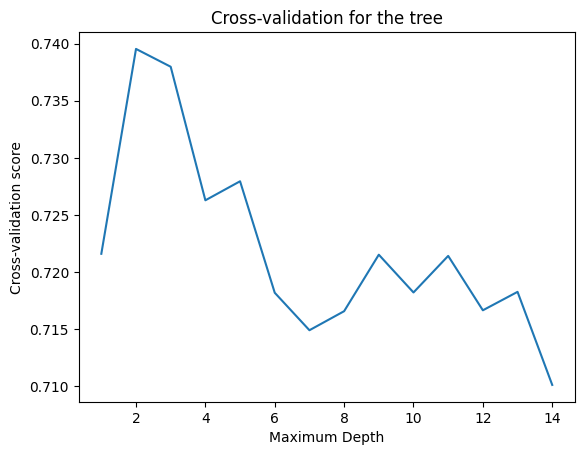

In [69]:
# Maximun depth of the tree
max_depth = range(1,15)
# List of cross-validation scores
scores = []
# For each depth, a new decision tree is trained and the cross-validation score is computed
for depth in max_depth:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    score = cross_val_score(tree, X_train, y_train, cv=10)
    scores.append(np.mean(score))

plt.plot(max_depth, scores)
plt.xlabel("Maximum Depth")
plt.ylabel("Cross-validation score")
plt.title("Cross-validation for the tree")
plt.show()

In [71]:
best_depth = max_depth[np.argmax(scores)]
print("The best maximal depth is :", best_depth)

The best maximal depth is : 2


In [72]:
# Let's build the tree with the chosen depth
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

[Text(0.5, 0.8333333333333334, 'Glucose <= 127.5\ngini = 0.453\nsamples = 614\nvalue = [401, 213]'),
 Text(0.25, 0.5, 'Age <= 28.5\ngini = 0.314\nsamples = 390\nvalue = [314, 76]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.142\nsamples = 221\nvalue = [204, 17]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.454\nsamples = 169\nvalue = [110, 59]'),
 Text(0.75, 0.5, 'BMI <= 29.95\ngini = 0.475\nsamples = 224\nvalue = [87, 137]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.429\nsamples = 61\nvalue = [42, 19]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.4\nsamples = 163\nvalue = [45, 118]')]

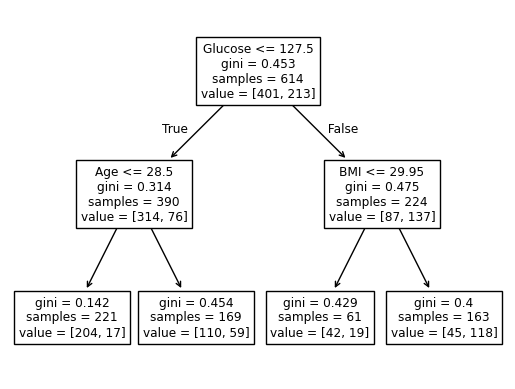

In [73]:
# Tree visualization
plot_tree(tree, feature_names=X.columns)
plt.show()

([<matplotlib.axis.XTick at 0x7b74bc80fdd0>,
 [Text(0, 0, 'Glucose'),
  Text(1, 0, 'BMI'),
  Text(2, 0, 'Age'),
  Text(3, 0, 'DiabetesPedigreeFunction'),
  Text(4, 0, 'Insulin'),
  Text(5, 0, 'SkinThickness'),
  Text(6, 0, 'BloodPressure'),
  Text(7, 0, 'Pregnancies')])

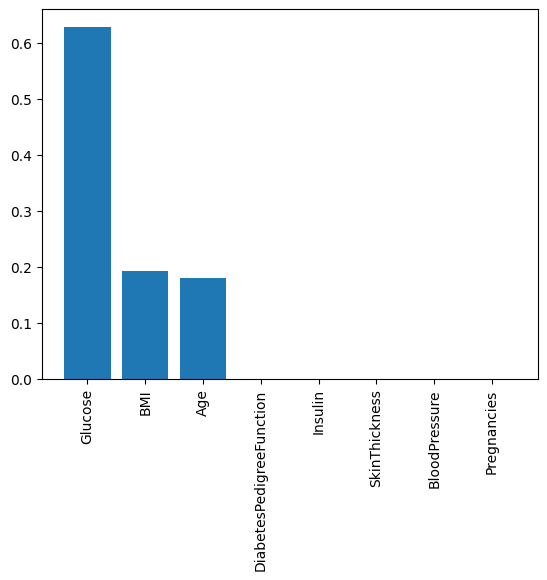

In [76]:
# Feature importances
importances = tree.feature_importances_
index = np.argsort(importances)[::-1]

plt.bar(range(X_train.shape[1]), importances[index])
plt.xticks(range(X_train.shape[1]), X.columns[index], rotation=90)

Evaluate the performance of the new model

In [77]:
# On the training dataset
# Prediction on the training dataset
y_train_pred = tree.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_confusion = confusion_matrix(y_train, y_train_pred)
train_classification = classification_report(y_train, y_train_pred)

print("Performance on the training dataset")
print("Train Accuracy : ", train_accuracy)
print("Train Confusion : \n", train_confusion)
print("Train Classification : \n", train_classification)

#On the test dataset
y_test_pred = tree.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
test_classification = classification_report(y_test, y_test_pred)

print("Performance on the test dataset")
print("Test Accuracy : ", test_accuracy)
print("Test Confusion : \n", test_confusion)
print("Test Classification : \n", test_classification)

Performance on the training dataset
Train Accuracy :  0.7719869706840391
Train Confusion : 
 [[356  45]
 [ 95 118]]
Train Classification : 
               precision    recall  f1-score   support

           0       0.79      0.89      0.84       401
           1       0.72      0.55      0.63       213

    accuracy                           0.77       614
   macro avg       0.76      0.72      0.73       614
weighted avg       0.77      0.77      0.76       614

Performance on the test dataset
Test Accuracy :  0.7727272727272727
Test Confusion : 
 [[87 12]
 [23 32]]
Test Classification : 
               precision    recall  f1-score   support

           0       0.79      0.88      0.83        99
           1       0.73      0.58      0.65        55

    accuracy                           0.77       154
   macro avg       0.76      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154

